In [48]:
import sys

sys.path.append(
    "/home/au672287/OpenFOAM/au672287-v2512/run/post/post"
)

import Post_new
import Plot_new

import importlib
importlib.reload(Post_new)
importlib.reload(Plot_new)

from Post_new import OpenFOAMRawCase
from Plot_new import plot_slice, plot_profiles, plot_profile_fields

import numpy as np

In [2]:
ofdir = '/home/au672287/OpenFOAM/au672287-v2512/run/projects/mesh_ind/50_100_j10'
savedir = '/home/au672287/OpenFOAM/au672287-v2512/run/post/mesh_ind/data'
case = OpenFOAMRawCase(ofdir)

In [59]:
slice_target = [0.02, 0.06, 0.1]
line_target = 0.025
times = np.linspace(0, 120, 5)
stime = 30
fields = ['c_Acetate','c_H2','c_CO2','c_O2']
plane = 'xy'
dim = 'y'
fix = 'xz'

title_slice = [f"z = {z*1e3} [mm]" for z in slice_target]
title_times = [f"t = {t} [s]" for t in times]

legend_species = [f"{f}" for f in fields]
legend_times = [f"{t} [s]" for t in times]

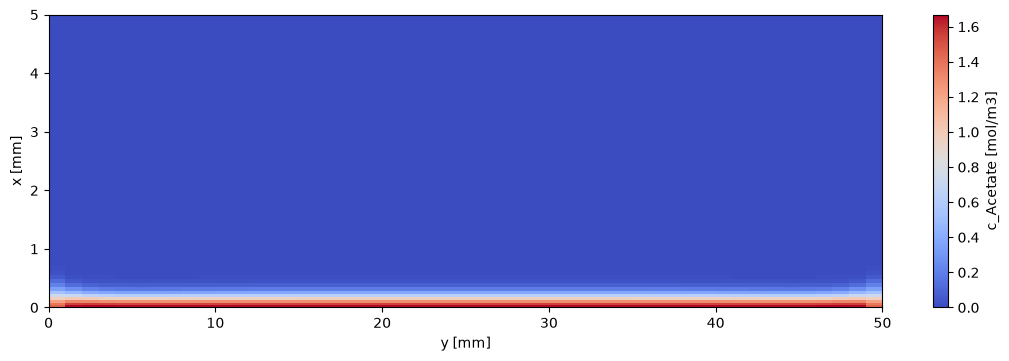

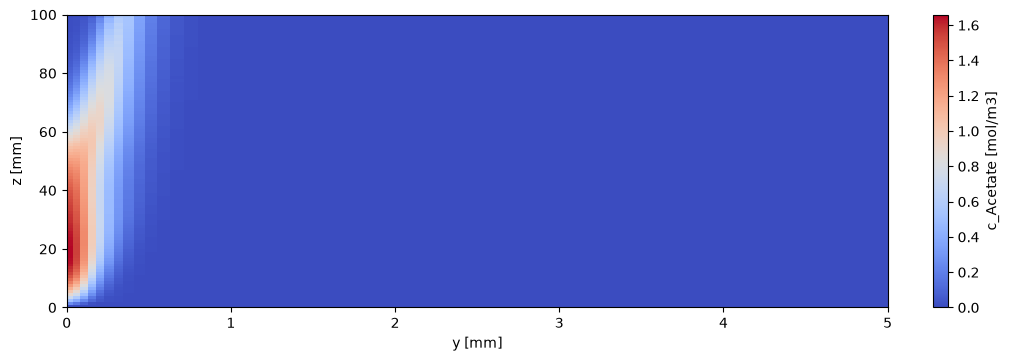

(<Figure size 1000x350 with 2 Axes>,
 [<Axes: xlabel='y [mm]', ylabel='z [mm]'>])

In [32]:
## Slice

# slice(self, time, field, plane, value):

# plot_slice(
    # S,
    # scale=1,
    # cmap="coolwarm",
    # size=(10, 3.5),
    # shared_colorbar=True,
    # colorbarname=None,
    # ixlabel='all',
    # iylabel='all',
    # xlabel=None,
    # ylabel=None,
    # title=None,
    # flip=None,
    # savedir=None,
    # savename=None,
    # dpi=300,
    # bbox_inches="tight",
# )

# Single 
S = case.slice(
    time=stime,
    field=fields[0],
    plane=plane,
    value=slice_target[0],
)

plot_slice(
    S,
    scale=1e3,
    colorbarname=f'{fields[0]} [mol/m3]',
    xlabel='y [mm]',
    ylabel='x [mm]',
)

S = case.slice(
    time=stime,
    field=fields[0],
    plane='yz',
    value=line_target,
)

plot_slice(
    S,
    scale=1e3,
    colorbarname=f'{fields[0]} [mol/m3]',
    xlabel='y [mm]',
    ylabel='z [mm]',
)

In [33]:
text = [f'z = {slice_target[0]} [mm]',f'z = {slice_target[1]} [mm]',f'z = {slice_target[2]} [mm]']
print(text)
print(text[0])

['z = 0.02 [mm]', 'z = 0.06 [mm]', 'z = 0.1 [mm]']
z = 0.02 [mm]


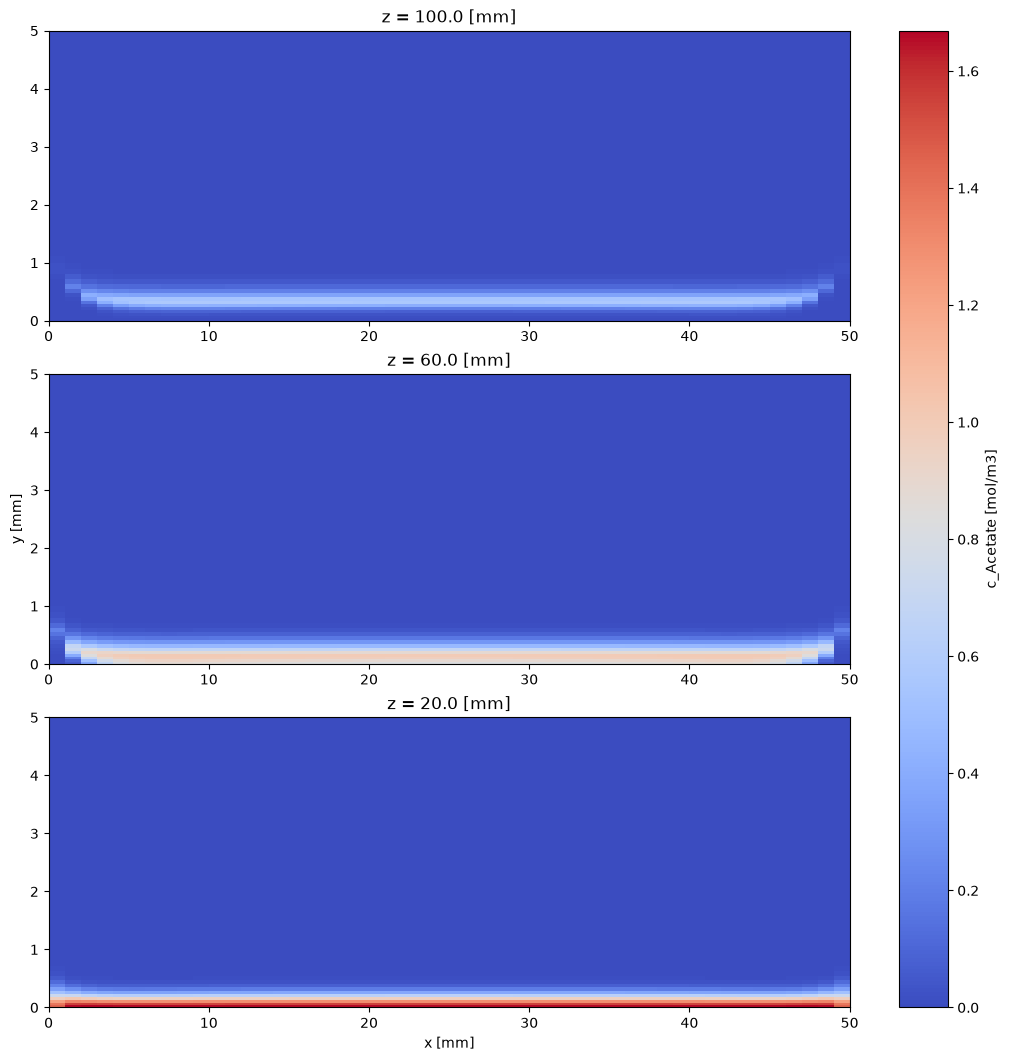

(<Figure size 1000x1050 with 4 Axes>,
 array([<Axes: title={'center': 'z = 100.0 [mm]'}>,
        <Axes: title={'center': 'z = 60.0 [mm]'}, ylabel='y [mm]'>,
        <Axes: title={'center': 'z = 20.0 [mm]'}, xlabel='x [mm]'>],
       dtype=object))

In [44]:
# Staced z 
S = []
for z in slice_target:
    s = case.slice(
        time=stime,
        field=fields[0],
        plane=plane,
        value=z,
    )
    S.append(s)
    
plot_slice(
    S,
    scale=1e3,
    colorbarname=f'{fields[0]} [mol/m3]',
    ixlabel=2,
    iylabel=1,
    xlabel='x [mm]',
    ylabel='y [mm]',
    title=title_slice[::-1],
    flip=True,
)


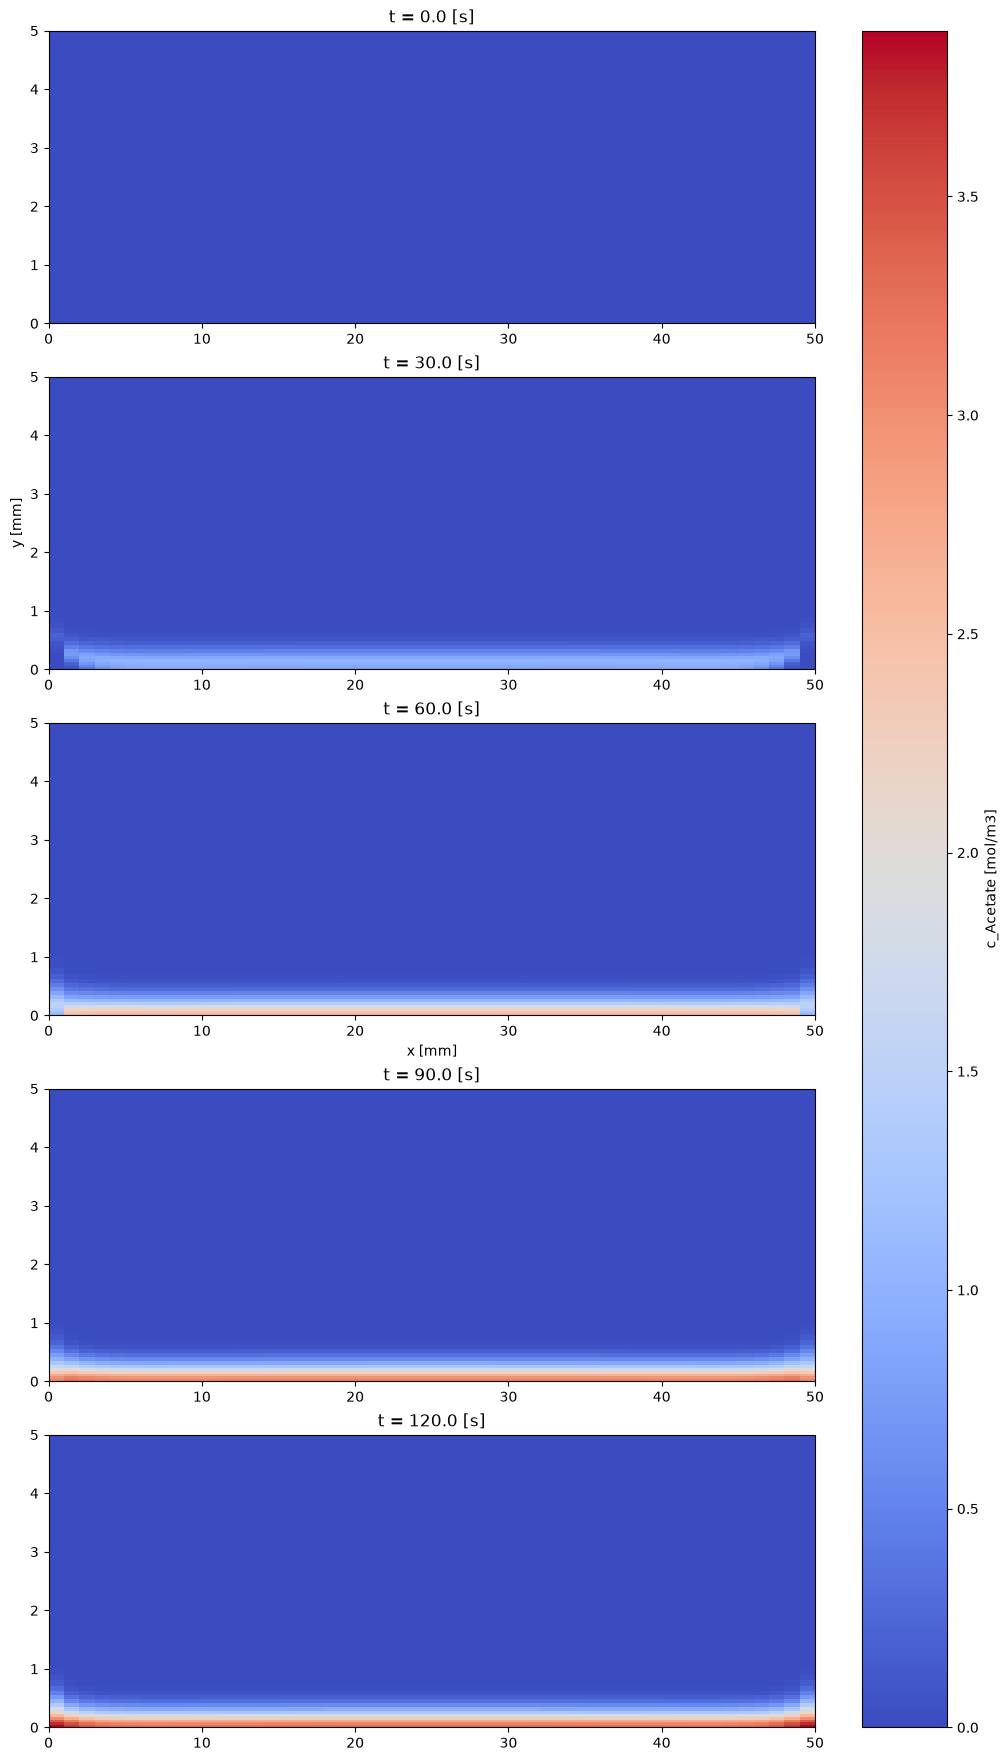

(<Figure size 1000x1750 with 6 Axes>,
 array([<Axes: title={'center': 't = 0.0 [s]'}>,
        <Axes: title={'center': 't = 30.0 [s]'}, ylabel='y [mm]'>,
        <Axes: title={'center': 't = 60.0 [s]'}, xlabel='x [mm]'>,
        <Axes: title={'center': 't = 90.0 [s]'}>,
        <Axes: title={'center': 't = 120.0 [s]'}>], dtype=object))

In [39]:
# Stacked times 
S = []
for t in times:
    s = case.slice(
        time=t,
        field=fields[0],
        plane=plane,
        value=slice_target[1],
    )
    S.append(s)
    
plot_slice(
    S,
    scale=1e3,
    colorbarname=f'{fields[0]} [mol/m3]',
    ixlabel=2,
    iylabel=1,
    xlabel='x [mm]',
    ylabel='y [mm]',
    title=title_times,
)


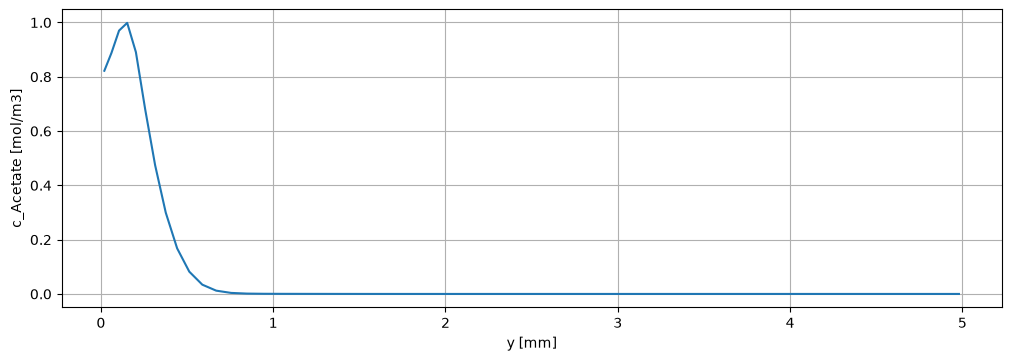

(<Figure size 1000x350 with 1 Axes>,
 [<Axes: xlabel='y [mm]', ylabel='c_Acetate [mol/m3]'>])

In [ ]:
## Profiles 

# Single 
P = case.profile(
        time=times[1],
        field=fields[0],
        along='y',
        fixed={'x': line_target, 'z': slice_target[1]},
        )

plot_profiles(
    P,
    scale=1e3,
    xlabel='y [mm]',
    ylabel=f'{fields[0]} [mol/m3]',
)

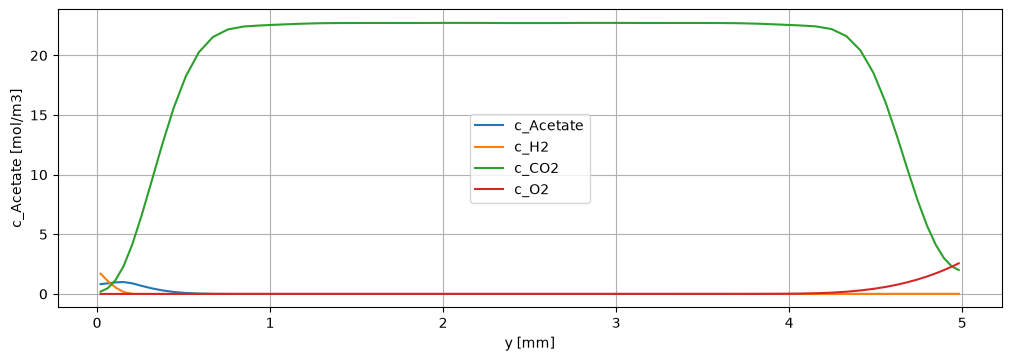

(<Figure size 1000x350 with 1 Axes>,
 [<Axes: xlabel='y [mm]', ylabel='c_Acetate [mol/m3]'>])

In [ ]:

# Single + fields 
P = []
for f in fields:
    p = case.profile(
        time=times[1],
        field=f,
        along='y',
        fixed={'x': line_target, 'z': slice_target[1]}
        )
    P.append(p)

plot_profiles(
    P,
    scale=1e3,
    xlabel='y [mm]',
    ylabel=f'{fields[0]} [mol/m3]',
    legend=legend_species
)

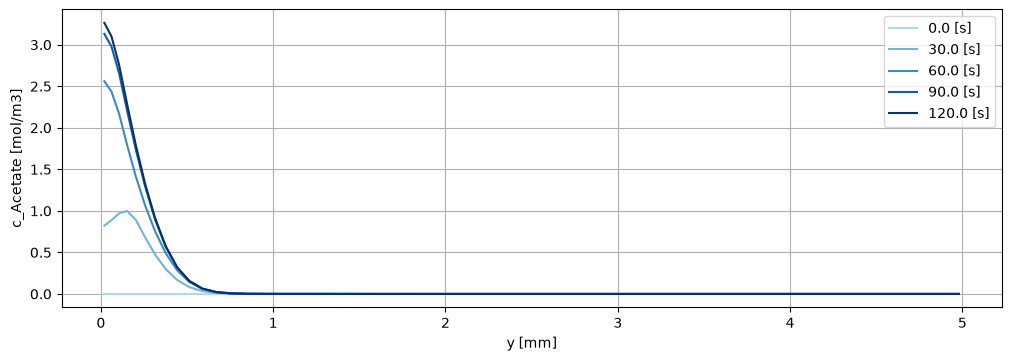

(<Figure size 1000x350 with 1 Axes>,
 [<Axes: xlabel='y [mm]', ylabel='c_Acetate [mol/m3]'>])

In [ ]:
# Single + times 
P = []
for t in times:
    p = case.profile(
        time=t,
        field=fields[0],
        along='y',
        fixed={'x': line_target, 'z': slice_target[1]}
        )
    P.append(p)

plot_profiles(
    P,
    scale=1e3,
    xlabel='y [mm]',
    ylabel=f'{fields[0]} [mol/m3]',
    legend=legend_times,
    color='Blues'
)

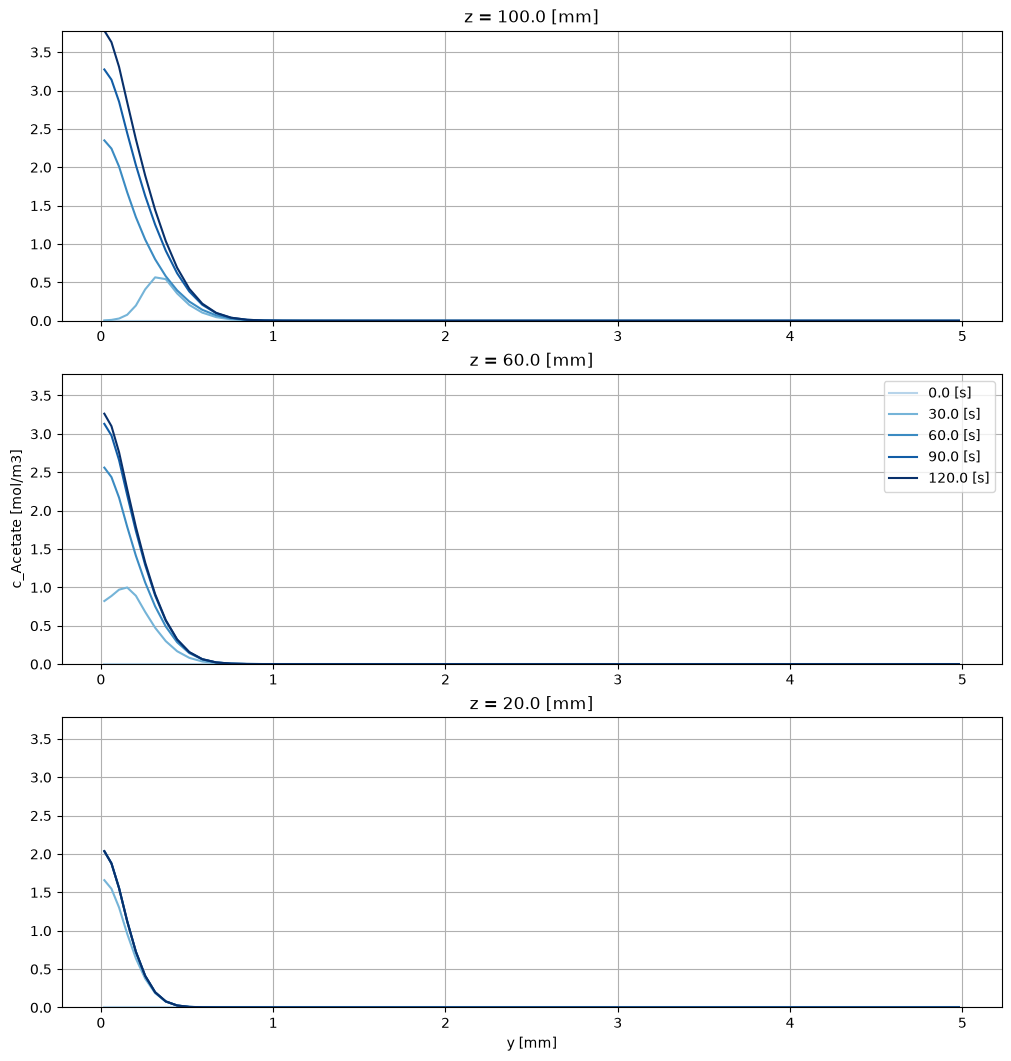

(<Figure size 1000x1050 with 3 Axes>,
 array([<Axes: title={'center': 'z = 100.0 [mm]'}>,
        <Axes: title={'center': 'z = 60.0 [mm]'}, ylabel='c_Acetate [mol/m3]'>,
        <Axes: title={'center': 'z = 20.0 [mm]'}, xlabel='y [mm]'>],
       dtype=object))

In [ ]:
# Stacked z + time 
P = []
for z in slice_target:
    pt = []
    for t in times: 
        p = case.profile(
            time=t,
            field=fields[0],
            along='y',
            fixed={'x': line_target, 'z': z}
            )
        pt.append(p)
    P.append(pt)

plot_profiles(
    P,
    scale=1e3,xlabel='y [mm]',
    ylabel=f'{fields[0]} [mol/m3]',
    legend=legend_times,
    color='Blues',
    title=title_slice[::-1],
    ixlabel=2,
    iylabel=1,
    ilegend=1,
    flip=True,
    shared_ylim=True
)


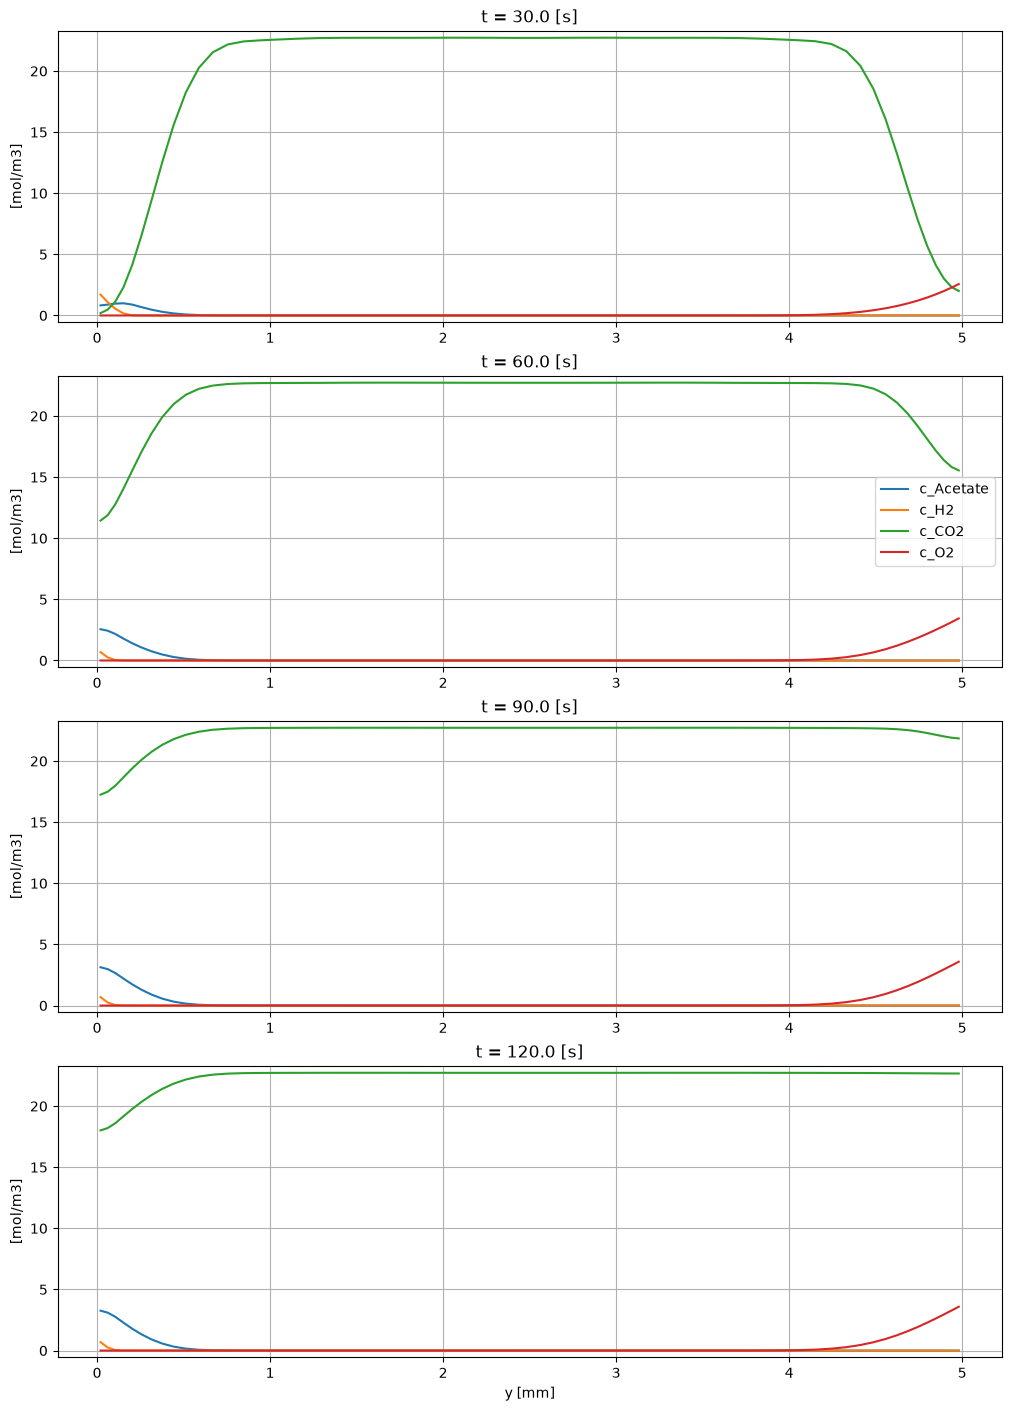

(<Figure size 1000x1400 with 4 Axes>,
 array([<Axes: title={'center': 't = 30.0 [s]'}, ylabel='[mol/m3]'>,
        <Axes: title={'center': 't = 60.0 [s]'}, ylabel='[mol/m3]'>,
        <Axes: title={'center': 't = 90.0 [s]'}, ylabel='[mol/m3]'>,
        <Axes: title={'center': 't = 120.0 [s]'}, xlabel='y [mm]', ylabel='[mol/m3]'>],
       dtype=object))

In [87]:
# stacked time + fields 
import importlib
importlib.reload(Post_new)
importlib.reload(Plot_new)

from Post_new import OpenFOAMRawCase
from Plot_new import plot_slice, plot_profiles, plot_profile_fields

P = []
for t in times[1:]:
    pt = []
    for f in fields: 
        p = case.profile(
            time=t,
            field=f,
            along='y',
            fixed={'x': line_target, 'z': slice_target[1]}
            )
        pt.append(p)
    P.append(pt)

plot_profiles(
    P,
    scale=1e3,
    xlabel='y [mm]',
    ylabel='[mol/m3]',
    legend=legend_species,
    title=title_times[1:],
    ixlabel=3,
    ilegend=1,
    shared_ylim=True,
    pad=0.025
)

